# Imputation for continous variables on the OWID dataset

## 1. Import dataset

In [1]:
import os
import sys

sys.path.append(os.path.abspath(".."))   # Add root path to sys.path
os.chdir("..")  # Change working directory to root path

### 1.1. OWID dataset

In [2]:
import pandas as pd

data_path = "data/original/owid_new_2025.csv"
original_df = pd.read_csv(data_path)

original_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 379242 entries, 0 to 379241
Data columns (total 14 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   iso_code                        379242 non-null  object 
 1   continent                       379242 non-null  object 
 2   location                        379242 non-null  object 
 3   date                            379242 non-null  object 
 4   new_cases_smoothed_per_million  379242 non-null  float64
 5   people_vaccinated_per_hundred   60446 non-null   float64
 6   stringency_index                193529 non-null  float64
 7   population                      379242 non-null  float64
 8   population_density              378472 non-null  float64
 9   median_age                      377947 non-null  float64
 10  total_tests_per_thousand        78254 non-null   float64
 11  classification                  347419 non-null  object 
 12  Overall_score   

### 1.2. Previous imputed dataset

- **Idea**: use the manually-collected data from the previous imputed dataset.

In [3]:
previous_imputed_df = pd.read_csv("data/original/idp_MissForest_2024.csv")

previous_imputed_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232 entries, 0 to 231
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   iso_code            232 non-null    object 
 1   continent           232 non-null    object 
 2   location            232 non-null    object 
 3   median_age          232 non-null    float64
 4   population          232 non-null    int64  
 5   population_density  232 non-null    float64
 6   classification      232 non-null    object 
 7   Overall_score       232 non-null    float64
 8   group               232 non-null    object 
 9   first_case          232 non-null    object 
 10  duration            232 non-null    int64  
 11  status              232 non-null    bool   
dtypes: bool(1), float64(3), int64(2), object(6)
memory usage: 20.3+ KB


## 2. Imputation
2-stage imputation:
- **Manual imputation**: some data () are imputed manually based on the trusted sources (e.g., WHO, World Bank, etc.). Some of these columns include:
    1. `median_age`
    2. `classification`
    3. `Overall_score`
    4. `group`

- **Random Forest imputation**: the remaining missing values are imputed using Random Forest, which is a powerful machine learning algorithm that can capture complex relationships between variables. These columns include time-dependent features, such as:
    1. `people_vaccinated_per_hundred`
    2. `stringency_index`
    3. `total_tests_per_thousand`

### 2.1 Manual imputation

In [4]:
original_df: pd.DataFrame = original_df.copy()

manual_columns = ["median_age", "classification", "Overall_score", "group", "population_density"]

# Manually imputed values from the previous imputed dataset
for col in manual_columns:
    missing_isocodes = original_df[original_df[col].isna()]["iso_code"].unique()
    for iso in missing_isocodes:
        if iso not in previous_imputed_df["iso_code"].values:
            print(f"Warning: iso_code {iso} not found in previous imputed dataset of {col}. Skipping.")
            continue
        imputed_value = previous_imputed_df[previous_imputed_df["iso_code"] == iso][col].values[0]
        original_df.loc[original_df["iso_code"] == iso, col] = imputed_value

original_df.dropna(subset=manual_columns, inplace=True)
original_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 379207 entries, 0 to 379241
Data columns (total 14 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   iso_code                        379207 non-null  object 
 1   continent                       379207 non-null  object 
 2   location                        379207 non-null  object 
 3   date                            379207 non-null  object 
 4   new_cases_smoothed_per_million  379207 non-null  float64
 5   people_vaccinated_per_hundred   60446 non-null   float64
 6   stringency_index                193529 non-null  float64
 7   population                      379207 non-null  float64
 8   population_density              379207 non-null  float64
 9   median_age                      379207 non-null  float64
 10  total_tests_per_thousand        78254 non-null   float64
 11  classification                  379207 non-null  object 
 12  Overall_score        

### 2.2 Contiguous imputation

- **Idea**: Implement XGBoost regression with *monotonic constraints* to impute the missing values for the time-dependent features.
    + **Monotonic constraints**: when impute a missing columns, create a lagged feature, i.e. `prev_value` to apply the constraint.

### 2.2.1 Preprocessing

In [21]:
# Convert vaccinated and test columns to their deltas to handle non-decreasing nature
processed_df = original_df.copy()

continuous_columns = ["total_tests_per_thousand", "stringency_index", "people_vaccinated_per_hundred"]
index_columns = ["iso_code", "location"]

# Convert columns to numeric
## Handle date
processed_df['date'] = pd.to_datetime(processed_df['date'], format='%Y-%m-%d')
first_date = processed_df['date'].min()
processed_df['date'] = (processed_df['date'] - first_date).dt.days

## Handle categorical columns => convert to dummy variables
# process categorical columns => one-hot encoding
categiorical_columns = [c for c in processed_df.columns if processed_df[c].dtype == 'object' and c not in index_columns]
encoded_categorial_columns = []

for c in categiorical_columns:
    # process categorical columns to remove excessive part, i.e. "\t", " ", etc.
    processed_df[c] = processed_df[c].str.strip()
    dummies = pd.get_dummies(processed_df[c], prefix=c)

    # drop the first dummy column to avoid multicollinearity
    dummies.drop(columns=dummies.columns[0], inplace=True)
    encoded_categorial_columns.extend(dummies.columns)
    
    dummies = dummies.astype(int)
    processed_df = pd.concat([processed_df, dummies], axis=1)
    processed_df.drop(columns=[c], inplace=True)

processed_df.drop(columns=["location"], inplace=True)
processed_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 379207 entries, 0 to 379241
Data columns (total 21 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   iso_code                            379207 non-null  object 
 1   date                                379207 non-null  int64  
 2   new_cases_smoothed_per_million      379207 non-null  float64
 3   people_vaccinated_per_hundred       60446 non-null   float64
 4   stringency_index                    193529 non-null  float64
 5   population                          379207 non-null  float64
 6   population_density                  379207 non-null  float64
 7   median_age                          379207 non-null  float64
 8   total_tests_per_thousand            78254 non-null   float64
 9   Overall_score                       379207 non-null  float64
 10  continent_Asia                      379207 non-null  int64  
 11  continent_Europe               

### 2.2.2 Classes

1. **XGBVariableModel**: a class that encapsulates the XGBoost regression model for a specific variable.

2. **Tracker**: a class that tracks the imputation process, including the history of imputed values and the performance of the model.

3. **IterativeImputer**: a class that performs the iterative imputation process, using the XGBVariableModel and Tracker classes to impute missing values for multiple variables in a sequential manner.

In [ ]:
import pandas as pd
import numpy as np

from src.variables.base import VariableModel, Parameter
from xgboost import XGBRegressor

class XGBVariableModel(VariableModel):
    name: str
    missing_indices: pd.Index
    model: XGBRegressor
    predictors: list[str]
    is_monotonic: bool

    def __init__(self, name, missing_indices: pd.Index, predictors: list[str], is_monotonic=False):
        self.name = name
        self.missing_indices = missing_indices
        self.predictors = predictors
        self.is_monotonic = is_monotonic

    def _prepare_monotonic_task(self, df: pd.DataFrame):
        result_df: pd.DataFrame = df.copy()
        result_df = result_df.sort_values(by=["iso_code", "date"])

        result_df['lag_target'] = result_df.groupby("iso_code")[self.name].shift(1)
        result_df['lag_target'] = result_df['lag_target'].fillna(0)  # fill NA for the first entry of each group

        return result_df

    def _enforce_boundaries(self, imputed_series: pd.Series, original_data: pd.DataFrame) -> pd.Series:
        """
        Ensures imputed values stay between the last known 'start' 
        and next known 'end' observed values.
        """
        # 1. Get the ground truth (only observed values)
        truth_df: pd.DataFrame = original_data.copy()
        # mark imputed values as NA to find boundaries
        truth_df.loc[self.missing_indices, self.name] = pd.NA

        lower_bound = truth_df.groupby('iso_code')[self.name].ffill().fillna(0)  # fill NA for the first entry of each group with 0
        upper_bound = truth_df.groupby('iso_code')[self.name].bfill().fillna(np.inf)

        truth_df.loc[self.missing_indices, self.name] = imputed_series
        
        imputed_data = np.clip(truth_df[self.name], lower_bound, upper_bound)
        return imputed_data.loc[self.missing_indices]

    def fit(self, imputed_data: pd.DataFrame) -> list[Parameter]:
        if self.is_monotonic:
            train_df = self._prepare_monotonic_task(imputed_data)
            train_df = train_df.drop(index=self.missing_indices).copy()            
            X_train = train_df[self.predictors + ['lag_target']]
        else:
            train_df = imputed_data.drop(index=self.missing_indices).copy()
            X_train = train_df[self.predictors]

        y_train = train_df[self.name]

        constraints = tuple([1 if col == 'lag_target' and self.is_monotonic else 0 for col in X_train.columns])
        self.model: XGBRegressor = XGBRegressor(
            monotone_constraints=constraints,
            n_estimators=100,
            learning_rate=0.05,
            tree_method="hist" # 'hist' or 'gpu_hist' is required for monotonic constraints
        )
        
        self.model.fit(X_train, y_train)
        return []   # No additional parameters to return
    
    def sample(self, imputed_data: pd.DataFrame) -> list[float]:
        if self.model is None:
            raise ValueError("Model has not been fitted yet.")

        if self.is_monotonic:
            test_df = self._prepare_monotonic_task(imputed_data).copy()
            test_df = test_df.loc[self.missing_indices]
    
            X_test = test_df[self.predictors + ['lag_target']]
        else:
            test_df = imputed_data.loc[self.missing_indices].copy()
            X_test = test_df[self.predictors]

        imputed_values = self.model.predict(X_test)

        # enforce boundaries to ensure monotonicity and realistic imputed values
        return self._enforce_boundaries(imputed_values, imputed_data[['iso_code', self.name]]).tolist()

In [126]:
from dataclasses import dataclass, field

@dataclass
class VariableRecord:
    name: str
    params: list[Parameter]
    imputed_values: list[float]

@dataclass
class VariableHistory:
    name: str
    history: list[VariableRecord]
    iterations: list[int]

class ImputedValueConvergenceChecker:
    @staticmethod
    def check_convergence(history, threshold: float) -> bool:
        """
        Redesigned to detect 'directional drift' in cumulative data 
        and handle oscillations in standard features.
        """
        # 1. Need at least 3 iterations to detect directional drift
        if len(history.history) < 3:
            return False, 1.0 
        
        curr = np.array(history.history[-1].imputed_values)
        prev = np.array(history.history[-2].imputed_values)
        prev_prev = np.array(history.history[-3].imputed_values)
        
        # 2. Calculate step differences
        diff_now = curr - prev
        diff_before = prev - prev_prev
        
        # 3. Detect Directional Drift
        # If the sign of change is the same as the last iteration, 
        # the model is still 'pushing' the curve in a specific direction.
        # We calculate the percentage of indices that are moving in the same direction.
        same_direction = (np.sign(diff_now) == np.sign(diff_before)) & (np.abs(diff_now) > 1e-9)
        drift_ratio = np.mean(same_direction)
        
        # 4. Calculate Normalized Max Difference
        # Using Max ensures that we don't ignore localized shifts in a long series.
        abs_diff = np.abs(diff_now)
        
        # Scale by standard deviation to handle different feature units
        scale = np.std(curr) + 1e-8
        max_rel_diff = np.max(abs_diff) / scale

        # 5. Convergence Logic:
        # It has converged ONLY IF:
        # A) The biggest change is below the threshold.
        # B) It is NOT consistently drifting in one direction (drift_ratio < 0.7).
        is_converged = (max_rel_diff < threshold) and (drift_ratio < 0.7)
        
        # Return a composite score for logging
        return is_converged, max_rel_diff

class Tracker:
    variables: dict[str, VariableHistory]
    convergence_threshold: float

    def __init__(self, missing_variables: list[str], convergence_threshold: float = 1e-3):
        self.variables = {
            var: VariableHistory(name=var, history=[], iterations=[]) \
                for var in missing_variables
        }
        self.convergence_threshold = convergence_threshold

    def record(self, iteration: int, variable_record: VariableRecord):
        var_name = variable_record.name
        self.variables[var_name].history.append(variable_record)
        self.variables[var_name].iterations.append(iteration)
    
    def get_current_data(self) -> dict[str, list[float]]:
        """
        Return the current imputed dataset.
        """
        current_data = {}
        for var_name, history in self.variables.items():
            if history.history:
                current_data[var_name] = history.history[-1].imputed_values
            else:
                raise ValueError(f"No history found for variable {var_name}. Cannot get current data.")
        
        return current_data

    def check_convergence(self) -> tuple[bool, list[tuple[str, float]]]:
        non_converged = []
        for _, history in self.variables.items():
            is_converged, mean_diff = ImputedValueConvergenceChecker.check_convergence(history, self.convergence_threshold)
            if not is_converged:
                non_converged.append((history.name, mean_diff))
        return len(non_converged) == 0, non_converged

In [127]:
from tqdm import tqdm
from time import time

MAX_ITERATIONS = 100

class IterativeImputer:
    variables: list[XGBVariableModel]
    original_df: pd.DataFrame
    tracker: Tracker
    max_iterations: int

    def __init__(self, variables: list[XGBVariableModel], original_df: pd.DataFrame, tracker: Tracker, max_iterations: int = MAX_ITERATIONS):
        self.variables = variables
        self.original_df = original_df
        self.tracker = tracker
        self.max_iterations = max_iterations
    
    def _initialize_imputation(self):
        """
        Iteration 0: fill missing values with initial imputation. For cumulative variables, i.e. monotonic=1, we can use forward fill to ensure monotonicity from the start.
        """
        df0 = self.original_df.copy()

        for variable in self.variables:
            if variable.is_monotonic:
                df0[variable.name] = df0.groupby('iso_code')[variable.name].ffill()
                df0[variable.name] = df0[variable.name].fillna(0)  # In case the first value is NA, fill it with 0
            else:
                df0[variable.name] = df0[variable.name].fillna(0)
            
            # Record the initial imputed values for iteration 0
            self.tracker.record(0, VariableRecord(
                name=variable.name,
                params=[],
                imputed_values=df0.loc[variable.missing_indices, variable.name].tolist())
            )
    
    def get_current_data(self) -> pd.DataFrame:
        """
        Construct the current imputed dataset based on the latest imputed values in the tracker.
        """
        current_data_dict = self.tracker.get_current_data() # get the latest imputed values into the tracker
        imputed_df = self.original_df.copy()

        for var_name, imputed_values in current_data_dict.items():
            # get current variable model to retrieve the missing indices
            current_var = self.variables[self.variables.index(next(v for v in self.variables if v.name == var_name))]
            imputed_df.loc[current_var.missing_indices, var_name] = imputed_values

        return imputed_df

    def run(self):
        log_str = f"Iteration 0: Initial imputation completed."
        def _add_splitter(s, new_iteration=None):
            if new_iteration is not None:
                return s + "\n\n" + f"  ITERATION {new_iteration}  ".center(60, "=") + "\n\n"
            return s + "\n" + f"{'-' * 20}".center(60, " ") + "\n"
        
        try:
            self._initialize_imputation()
            log_str = _add_splitter(log_str)

            pbar = tqdm(range(1, self.max_iterations))
            for iteration in pbar:
                log_str = _add_splitter(log_str, new_iteration=iteration)
                for variable in self.variables:
                    begin_time = time()
                    pbar.set_description(f"Retrieving data - {variable.name}")
                    last_imputed_data = self.get_current_data()

                    pbar.set_description(f"Fitting model - {variable.name}")
                    parameters = variable.fit(last_imputed_data)

                    pbar.set_description(f"Sampling - {variable.name}")
                    imputed_values = variable.sample(last_imputed_data)

                    self.tracker.record(iteration, VariableRecord(
                        name=variable.name,
                        params=parameters,
                        imputed_values=imputed_values
                    ))
                    end_time = time()
                    log_str += f"Variable {variable.name[:10]}...:\nImputed in {end_time - begin_time:.2f} seconds.\nAverage imputed value: {np.mean(imputed_values):.4f}\n"
                    log_str = _add_splitter(log_str)

                # check convergence after each iteration
                pbar.set_description(f"Checking convergence")
                is_converged, non_converged_variables = self.tracker.check_convergence()
                if is_converged:
                    log_str += f"Convergence reached at iteration {iteration}.\n"
                    break
                else:
                    log_str += f"Variables not converged: {', '.join([f'{name}: {diff:.4f}' for name, diff in non_converged_variables])}\n"
        except Exception as e:
            log_str += f"Error occurred at iteration {iteration}: {str(e)}\n"
            raise e
        finally:
            print(log_str)

### 2.2.3 Imputation process

In [130]:
missing_columns = [col for col in continuous_columns if processed_df[col].isna().any()]
index_columns = ["iso_code", "location"]
missing_variables: list[XGBVariableModel] = []

for col in missing_columns:
    is_monotonic = col in ["total_tests_per_thousand", "people_vaccinated_per_hundred"]
    missing_variables.append(XGBVariableModel(
        name=col,
        missing_indices=processed_df[processed_df[col].isna()].index,
        predictors=[c for c in processed_df.columns if c not in [col] + index_columns],
        is_monotonic=is_monotonic
    ))

tracker = Tracker(missing_columns, convergence_threshold=5e-2)

imputer = IterativeImputer(
    variables=missing_variables, original_df=processed_df, 
    tracker=tracker, max_iterations=300
)

imputer.run()

Checking convergence: 100%|██████████| 299/299 [21:35<00:00,  4.33s/it]                           

Iteration 0: Initial imputation completed.
                    --------------------                    


======================  ITERATION 1  =======================

Variable total_test...:
Imputed in 0.90 seconds.
Average imputed value: 949.3922

                    --------------------                    
Variable people_vac...:
Imputed in 0.90 seconds.
Average imputed value: 33.2237

                    --------------------                    
Variable stringency...:
Imputed in 0.83 seconds.
Average imputed value: 24.8819

                    --------------------                    
Variables not converged: total_tests_per_thousand: 1.0000, people_vaccinated_per_hundred: 1.0000, stringency_index: 1.0000


======================  ITERATION 2  =======================

Variable total_test...:
Imputed in 0.90 seconds.
Average imputed value: 1006.8704

                    --------------------                    
Variable people_vac...:
Imputed in 0.92 seconds.
Average imputed value: 33

### 2.2.4 Optimize monotonic constraints

In [199]:
from sklearn.isotonic import IsotonicRegression
import numpy as np
import pandas as pd

def optimize_monotonic_sequence(series: pd.Series, missing_indices: pd.Index) -> pd.Series:
    """
    Solves the quadratic programming problem for monotonic constraints
    using weighted Isotonic Regression.
    """
    # 1. Prepare data
    y = series.values
    x = np.arange(len(y))
    
    # 2. Assign Weights: 
    # High weight for observed values (anchors), low for imputed
    weights = np.ones(len(y))
    # We use a large but stable weight (e.g., 1e5) for anchors
    observed_mask = ~series.index.isin(missing_indices)
    weights[observed_mask] = 1e6 
    
    # 3. Fit Isotonic Regression
    # out_of_bounds='clip' handles potential edge cases
    ir = IsotonicRegression(increasing=True, out_of_bounds='clip')
    
    # y_optimized will be the sequence that minimizes sum((y_opt - y)^2)
    # subject to y_opt[i] <= y_opt[i+1]
    y_optimized = ir.fit_transform(x, y, sample_weight=weights)
    
    return pd.Series(y_optimized, index=series.index)

optimized_df = imputer.get_current_data()
for iso_code in tqdm(optimized_df['iso_code'].unique()):
    for col in ["total_tests_per_thousand", "people_vaccinated_per_hundred"]:
        series = optimized_df[optimized_df['iso_code'] == iso_code][col]
        missing_indices = original_df[original_df['iso_code'] == iso_code][col].index[original_df[original_df['iso_code'] == iso_code][col].isna()]
        if len(missing_indices) > 0:
            optimized_series = optimize_monotonic_sequence(series, missing_indices)
            optimized_df.loc[missing_indices, col] = optimized_series.loc[missing_indices]

optimized_df

100%|██████████| 233/233 [00:37<00:00,  6.13it/s]


,iso_code,date,new_cases_smoothed_per_million,people_vaccinated_per_hundred,stringency_index,population,population_density,median_age,total_tests_per_thousand,Overall_score,...,continent_Europe,continent_North America,continent_Oceania,continent_South America,classification_LOW-INCOME,classification_LOWER-MIDDLE INCOME,classification_UPPER-MIDDLE-INCOME,group_Flawed democracy,group_Full democracy,group_Hybrid regime
0,AFG,0,0.0,0.000000,0.0,41128772.0,54.422,18.6,6.183742,0.26,...,0,0,0,0,1,0,0,0,0,0
1,AFG,1,0.0,0.000000,0.0,41128772.0,54.422,18.6,12.044991,0.26,...,0,0,0,0,1,0,0,0,0,0
2,AFG,2,0.0,0.000000,0.0,41128772.0,54.422,18.6,18.040047,0.26,...,0,0,0,0,1,0,0,0,0,0
3,AFG,3,0.0,0.000000,0.0,41128772.0,54.422,18.6,21.272000,0.26,...,0,0,0,0,1,0,0,0,0,0
4,AFG,4,0.0,0.000000,0.0,41128772.0,54.422,18.6,21.272000,0.26,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
379237,ZWE,1664,0.0,64.744125,53.7,16320539.0,42.730,19.6,493.467377,2.98,...,0,0,0,0,0,1,0,0,0,0
379238,ZWE,1665,0.0,64.744125,53.7,16320539.0,42.730,19.6,493.467377,2.98,...,0,0,0,0,0,1,0,0,0,0
379239,ZWE,1666,0.0,64.744125,53.7,16320539.0,42.730,19.6,493.467377,2.98,...,0,0,0,0,0,1,0,0,0,0
379240,ZWE,1667,0.0,64.744125,53.7,16320539.0,42.730,19.6,493.467377,2.98,...,0,0,0,0,0,1,0,0,0,0


## 3. Visualization of imputation process

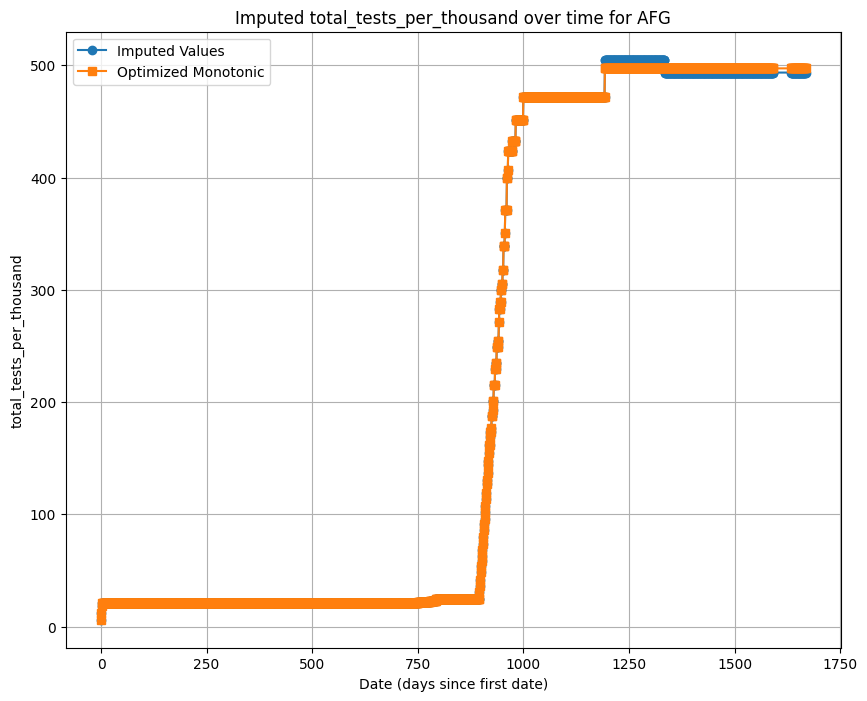

In [201]:
import matplotlib.pyplot as plt

# Get the current imputed dataset
# imputed_df = imputer.get_current_data()

plt.figure(figsize=(10, 8))
iso_code = 'AFG'  # example iso_code for America
column = 'total_tests_per_thousand'  # example column to plot

imputed_df = imputer.get_current_data()
plt.plot(imputed_df[imputed_df['iso_code'] == iso_code]['date'], imputed_df[imputed_df['iso_code'] == iso_code][column], marker='o', label='Imputed Values')

plt.plot(optimized_df[optimized_df['iso_code'] == iso_code]['date'], optimized_df[optimized_df['iso_code'] == iso_code][column], marker='s', label='Optimized Monotonic')

# plt.plot(original_df[original_df['iso_code'] == iso_code]['date'], original_df[original_df['iso_code'] == iso_code][column], marker='x', label='Original Values')

plt.title(f"Imputed {column} over time for {iso_code}")
plt.xlabel("Date (days since first date)")
plt.ylabel(column)
plt.legend()
plt.grid()
plt.show()

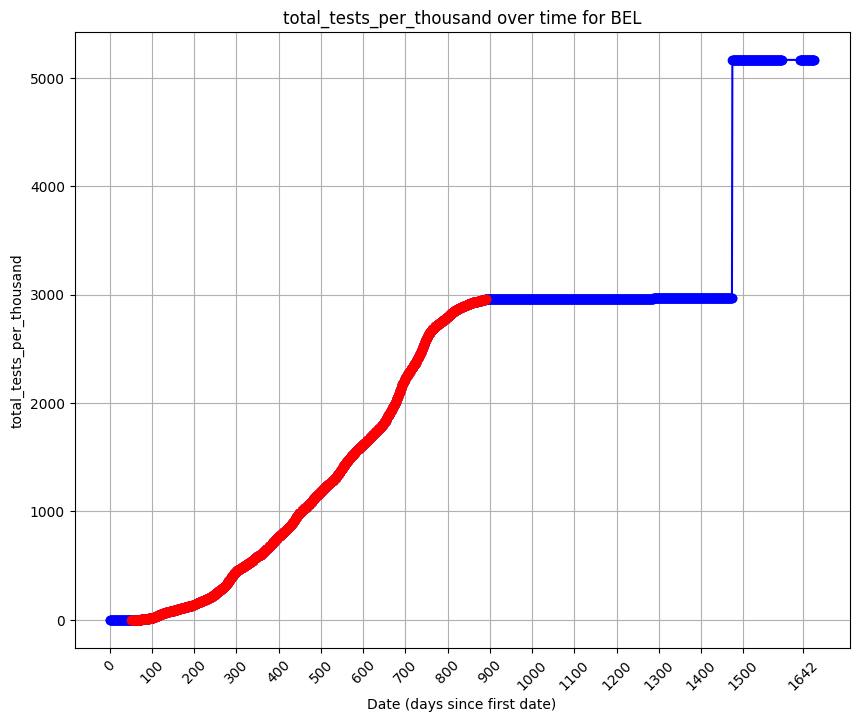

In [204]:
import matplotlib.pyplot as plt

# Get the current imputed dataset
# imputed_df = imputer.get_current_data()

plt.figure(figsize=(10, 8))
iso_code = 'BEL'  # example iso_code for America
column = 'total_tests_per_thousand'  # example column to plot

# plot imputed values
rows = optimized_df[optimized_df['iso_code'] == iso_code].dropna(subset=[column]).copy()
plt.plot(rows['date'], rows[column], marker='o', color='blue')

# plot original values
original_rows = processed_df[processed_df['iso_code'] == iso_code].dropna(subset=[column]).copy()
plt.plot(original_rows['date'], original_rows[column], marker='o', color='red')

# only keep some values on x-axis to avoid overcrowding
plt.xticks(rows['date'][::100], rotation=45)
plt.title(f'{column} over time for {iso_code}')
plt.xlabel('Date (days since first date)')
plt.ylabel(column)
plt.grid()

plt.show()

### 3.2 Check convergence of imputation process

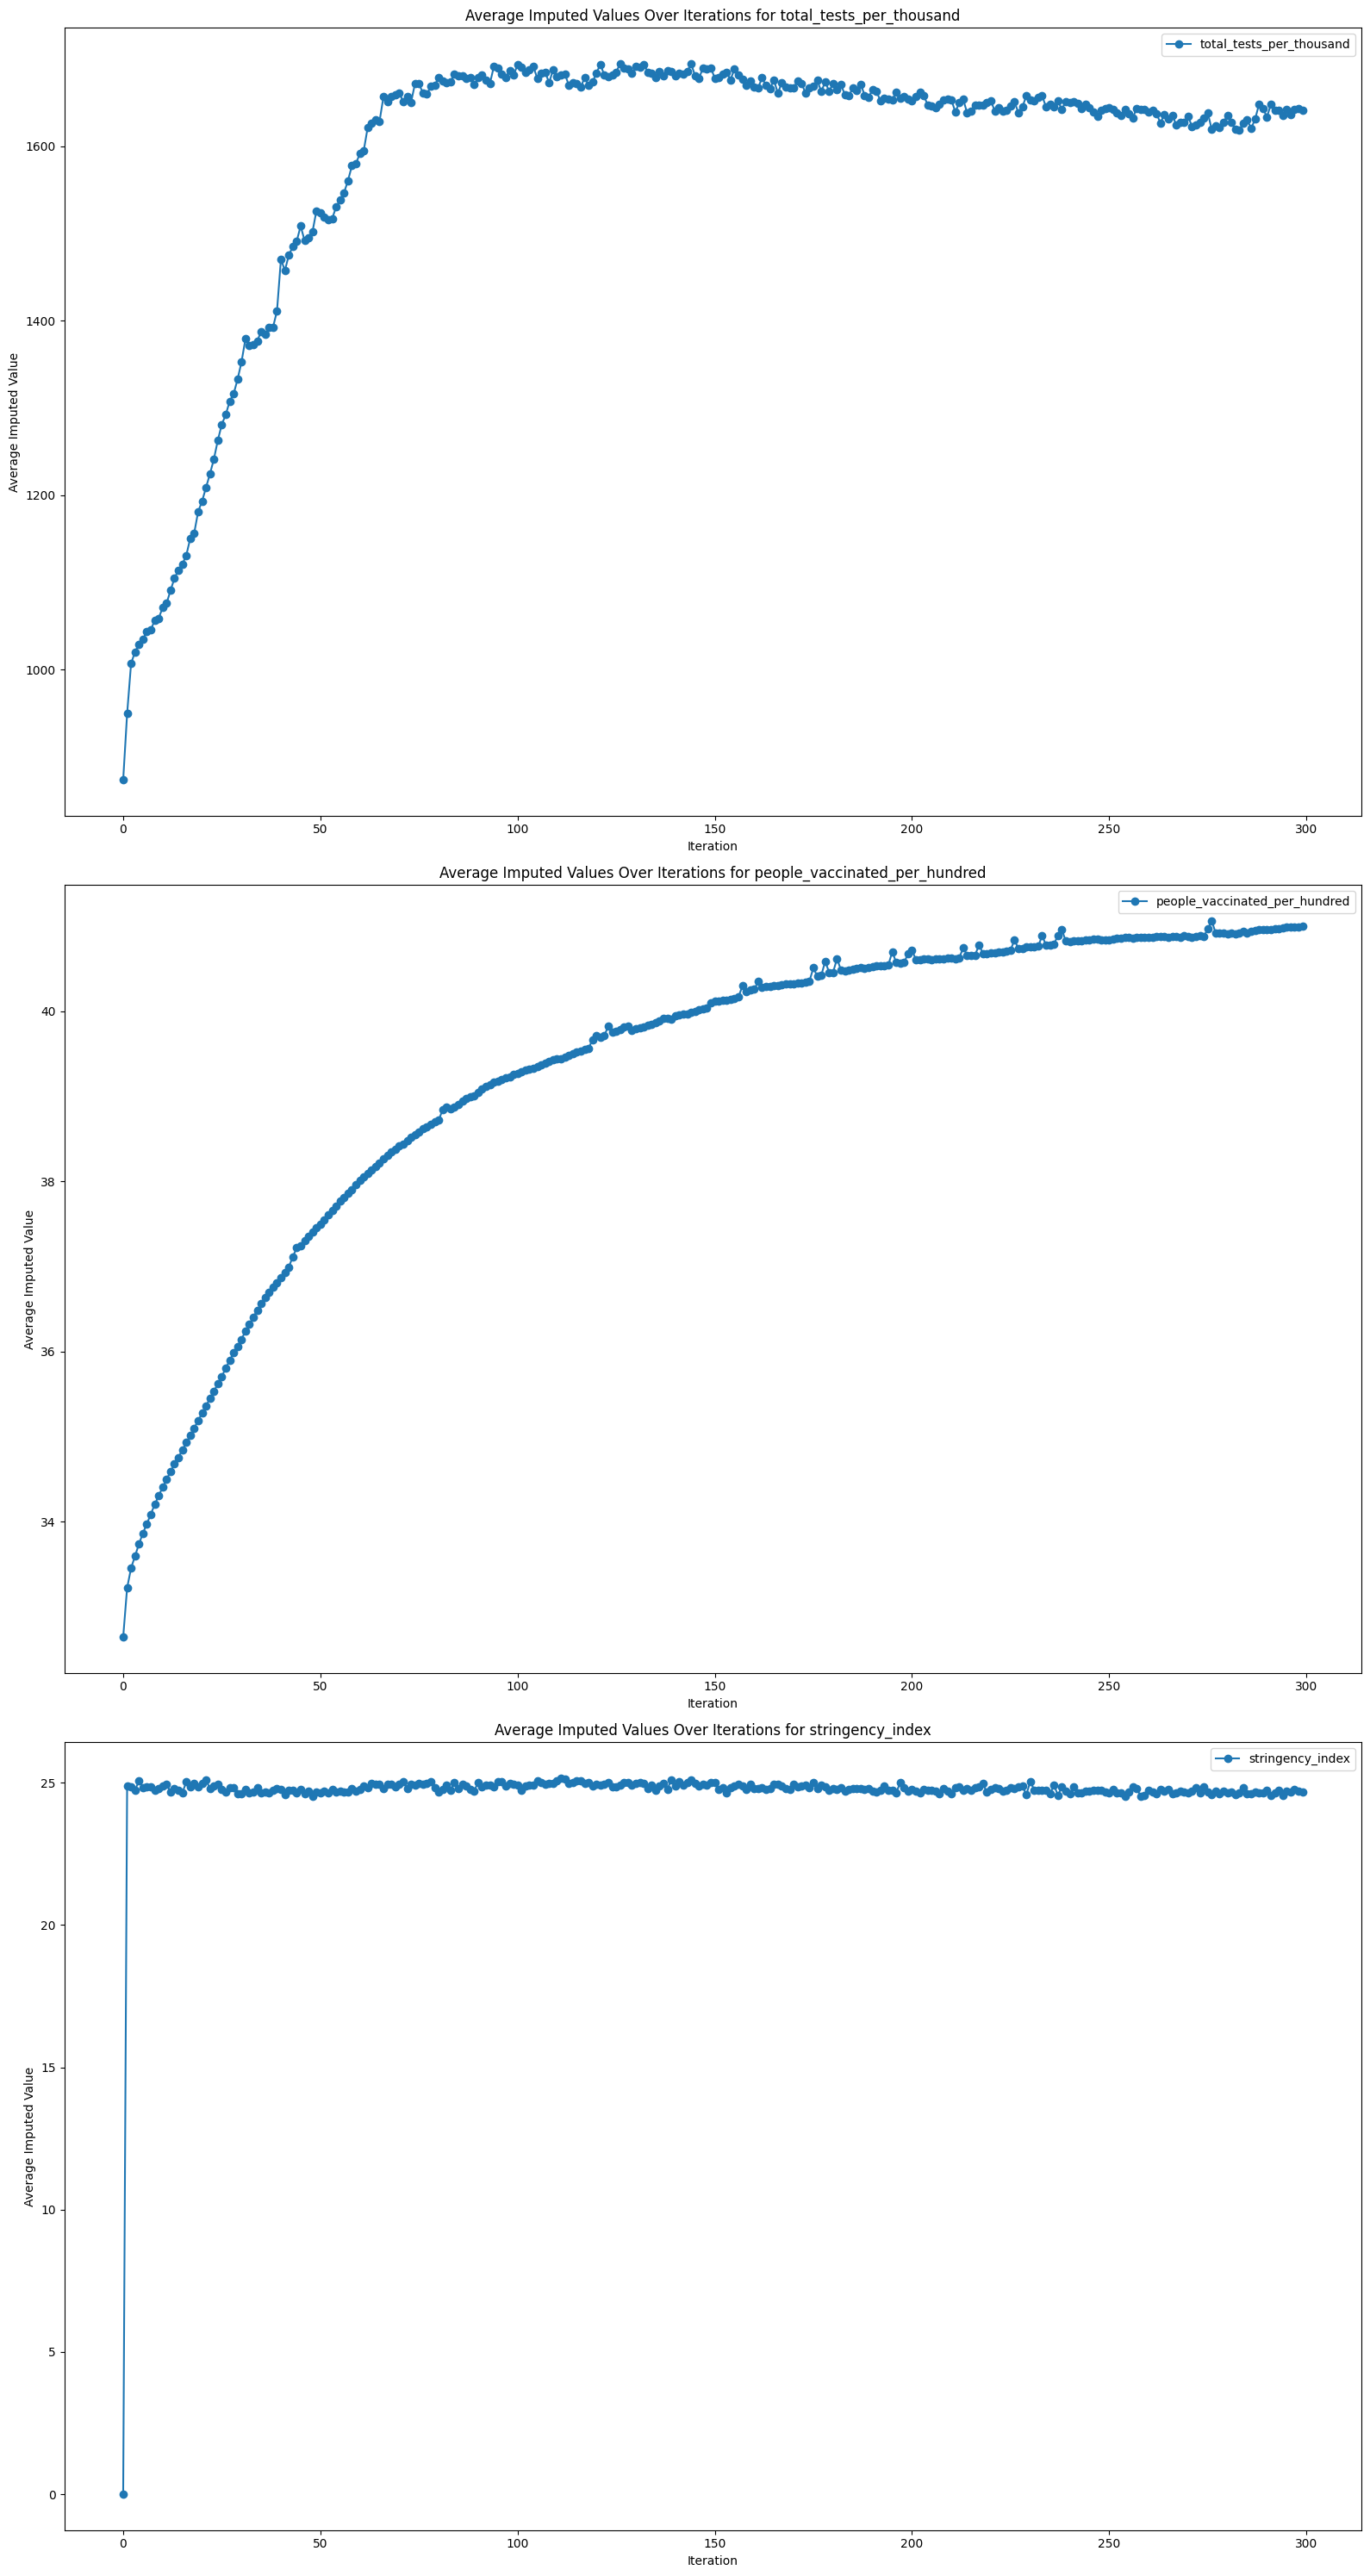

In [131]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 10 * len(tracker.variables)))
num_vars = len(tracker.variables)

for idx, (var_name, var_history) in enumerate(tracker.variables.items()):
    plt.subplot(num_vars, 1, idx + 1)
    avg_imputed_values = [np.mean(record.imputed_values) for record in var_history.history]
    iterations = var_history.iterations
    plt.plot(iterations, avg_imputed_values, marker='o', label=var_name)
    plt.title(f'Average Imputed Values Over Iterations for {var_name}')
    plt.xlabel('Iteration')
    plt.ylabel('Average Imputed Value')
    plt.legend()

plt.tight_layout()
plt.show()

## 4. Export the imputed dataset

In [205]:
owid_df = original_df.drop(columns=missing_columns).copy()
owid_df = pd.concat([owid_df, optimized_df[missing_columns]], axis=1).drop_duplicates(subset=['iso_code', 'date'], keep='last').reset_index(drop=True)

# Export the imputed OWID dataset
stored_path = "data/processed/owid_xgboost_imputed.csv"
if not os.path.exists(stored_path):
    os.makedirs(os.path.dirname(stored_path), exist_ok=True)
owid_df.to_csv(stored_path, index=False)
print(f"Imputed OWID dataset exported to {stored_path}")

owid_df = owid_df[['iso_code', 'date', *missing_columns]].drop_duplicates(subset=['iso_code', 'date'], keep='last').reset_index(drop=True)

# Merge with covariant data
covariate_df = pd.read_csv("data/original/covariant.csv")
covariate_df.drop(columns=missing_columns, inplace=True, errors='ignore')  # drop missing columns if they exist in covariate_df
final_df = pd.merge(covariate_df, owid_df, on=["iso_code", "date"], how="left")
final_df.info()

# Export the final imputed dataset
stored_path = "data/processed/covariant_owid_imputed.csv"
if not os.path.exists(stored_path):
    os.makedirs(os.path.dirname(stored_path), exist_ok=True)

final_df.to_csv(stored_path, index=False)
print(f"Imputed dataset exported to {stored_path}")

Imputed OWID dataset exported to data/processed/owid_xgboost_imputed.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11671 entries, 0 to 11670
Data columns (total 31 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   iso_code                        11671 non-null  object 
 1   continent                       11671 non-null  object 
 2   location                        11671 non-null  object 
 3   date                            11671 non-null  object 
 4   new_cases_smoothed_per_million  11671 non-null  float64
 5   population                      11671 non-null  float64
 6   median_age                      11671 non-null  float64
 7   classification                  11671 non-null  object 
 8   Overall_score                   11671 non-null  float64
 9   group                           11671 non-null  object 
 10  total_sequence                  11671 non-null  int64  
 11  recombinant         